<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week10_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [3]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [4]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Target and Features
X = df_BreastCancer.drop(["Diagnosis", "ID"], axis=1)
y = df_BreastCancer["Diagnosis"]

#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



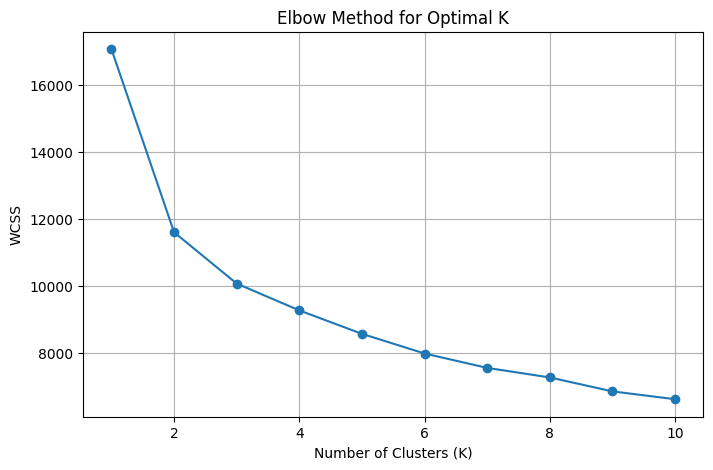

In [6]:
#Elbow Method
wcss = []

cluster_range = range(1,11)

for k in cluster_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.show()

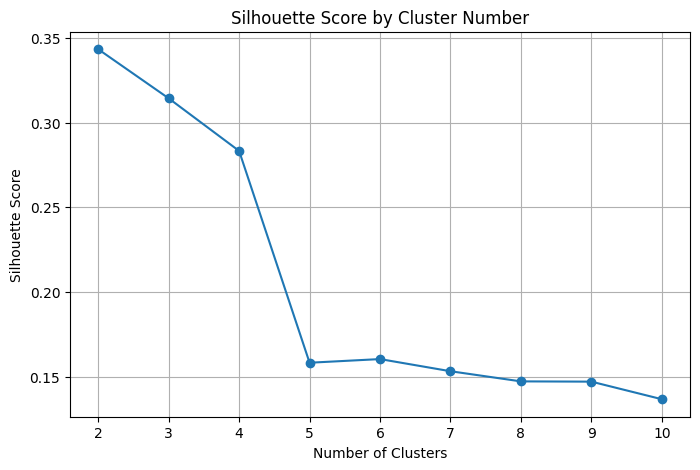

In [7]:
#Silhouette Score
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels)

    silhouette_scores.append(score)


plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Cluster Number")
plt.grid(True)

plt.show()

In [8]:
#Compare Distance Metrics
distance_metrics = [
    "euclidean",
    "manhattan"]


for metric in distance_metrics:

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        metric=metric)

    print(
        metric,
        "Silhouette Score:",
        round(score,4)
    )

euclidean Silhouette Score: 0.3434
manhattan Silhouette Score: 0.3814


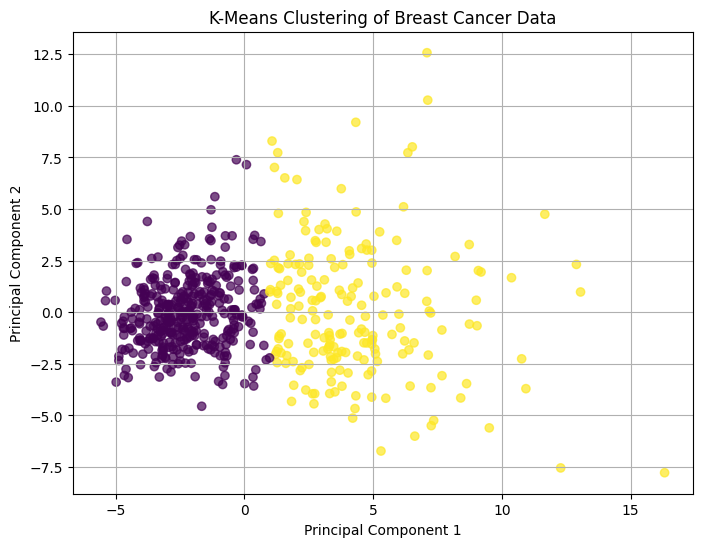

In [9]:
#PCA Visualization of Clusters
# Fit final KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# PCA reduction
pca = PCA(
    n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.7)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Breast Cancer Data")
plt.grid(True)
plt.show()

In [10]:
#Compare Clusters with Actual Diagnosis (Optional)
comparison = pd.DataFrame({
    "Actual Diagnosis": df_BreastCancer["Diagnosis"],
    "Cluster": clusters})

print(pd.crosstab(
        comparison["Actual Diagnosis"],
        comparison["Cluster"]))

Cluster             0    1
Actual Diagnosis          
0                  36  176
1                 339   18


In [12]:
#Comparison of feature scaling before and after
# Without scaling
kmeans_raw = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10)

clusters_raw = kmeans_raw.fit_predict(X)
print("Silhouette without scaling:",
    silhouette_score(X, clusters_raw))


# With scaling
kmeans_scaled = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_scaled = kmeans_scaled.fit_predict(X_scaled)
print("Silhouette with scaling:",
    silhouette_score(X_scaled, clusters_scaled))

Silhouette without scaling: 0.6972646156059465
Silhouette with scaling: 0.34338224069077805
